In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.interpolate import CubicSpline

BASE = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
DATA = BASE
RESULTS = BASE / 'results'
RESULTS.mkdir(exist_ok=True)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
                     'figure.dpi': 120, 'axes.titlepad': 14})
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)

def finish(fig, name):
    fig.savefig(RESULTS / name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def axes_style(ax, xlabel, ylabel, arrows=False):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    ax.grid(True, alpha=0.3)
    if arrows:
        # Направление возрастания обеих осей
        for end in [(1, 0), (0, 1)]:
            ax.annotate('', xy=end, xytext=(0, 0), xycoords='axes fraction',
                        arrowprops={'arrowstyle': '->', 'color': '#333333'},
                        annotation_clip=False)

## 1. Загрузка и преобразование данных
В первом файле разделитель — запятая, десятичный знак — точка.
Во втором разделитель — точка с запятой, десятичный знак — запятая.
Timestamp преобразуем по формату месяц/день/год, Data — день.месяц.год.
Power (kW) — мощность в кВт, а не энергия в кВт·ч.
OAT (F) трактуем как наружную температуру в °F по названию столбца
(Outside Air Temperature). Добавляем температуру в °C.
Проверяем пропуски, дубли времени, числовые типы и интервалы измерений.
Нулевую мощность сохраняем: без дополнительной информации её нельзя считать пропуском.

In [2]:
power = pd.read_csv(DATA / 'DataSet3_1.csv')
market = pd.read_csv(DATA / 'DataSet3_2.csv', sep=';', decimal=',')
power['Timestamp'] = pd.to_datetime(power['Timestamp'], format='%m/%d/%Y %H:%M')
market['Data'] = pd.to_datetime(market['Data'], format='%d.%m.%Y')
for col in ['OAT (F)', 'Power (kW)']:
    power[col] = pd.to_numeric(power[col], errors='raise')
for col in ['Dollar', 'Oil Brent']:
    market[col] = pd.to_numeric(market[col], errors='raise')
power = power.sort_values('Timestamp').reset_index(drop=True)
market = market.sort_values('Data').reset_index(drop=True)
power['Temperature (C)'] = (power['OAT (F)'] - 32) * 5 / 9

for name, frame, date_col in [('DataSet3_1', power, 'Timestamp'),
                              ('DataSet3_2', market, 'Data')]:
    print(f'{name}: {len(frame)} строк; период {frame[date_col].min()} — {frame[date_col].max()}')
    print('Типы:', frame.dtypes.astype(str).to_dict())
    print('Пропуски:', frame.isna().sum().to_dict())
    print('Дубли времени:', int(frame[date_col].duplicated().sum()))
    print('Интервалы:', frame[date_col].diff().value_counts().to_dict(), '\n')

assert len(power) >= 1000
assert not power.isna().any().any()
assert not power['Timestamp'].duplicated().any()
assert power['Timestamp'].diff().dropna().eq(pd.Timedelta(minutes=15)).all()
print(power[['Power (kW)', 'Temperature (C)']].describe().round(3))
print('Число нулевых значений мощности:', int(power['Power (kW)'].eq(0).sum()))

DataSet3_1: 34940 строк; период 2010-01-01 01:15:00 — 2010-12-31 00:00:00
Типы: {'Timestamp': 'datetime64[us]', 'OAT (F)': 'int64', 'Power (kW)': 'float64', 'Temperature (C)': 'float64'}
Пропуски: {'Timestamp': 0, 'OAT (F)': 0, 'Power (kW)': 0, 'Temperature (C)': 0}
Дубли времени: 0
Интервалы: {Timedelta('0 days 00:15:00'): 34939} 

DataSet3_2: 250 строк; период 2020-01-01 00:00:00 — 2020-12-31 00:00:00
Типы: {'Data': 'datetime64[us]', 'Dollar': 'float64', 'Oil Brent': 'float64'}
Пропуски: {'Data': 0, 'Dollar': 0, 'Oil Brent': 0}
Дубли времени: 0
Интервалы: {Timedelta('1 days 00:00:00'): 196, Timedelta('3 days 00:00:00'): 47, Timedelta('4 days 00:00:00'): 3, Timedelta('8 days 00:00:00'): 1, Timedelta('6 days 00:00:00'): 1, Timedelta('2 days 00:00:00'): 1} 

       Power (kW)  Temperature (C)
count   34940.000        34940.000
mean      261.645           14.770
std        65.673            4.855
min         0.000            0.556
25%       194.600           11.667
50%       276.700     

## 2. Четыре обязательных вида диаграмм
Каждый основной рисунок использует все 34 940 наблюдений.
На линейном рисунке дополнительно показаны первые 1000 значений для читаемости.
Столбцы показывают среднюю мощность по часам, круговая диаграмма — доли измерений
в диапазонах мощности, скрипичные — распределения по дням недели.
Агрегирование в категории не уменьшает число исходных наблюдений.
Оси подписаны, добавлена координатная сетка и стрелки направления осей.
У круговой диаграммы количественных осей нет: подписаны категории и проценты.

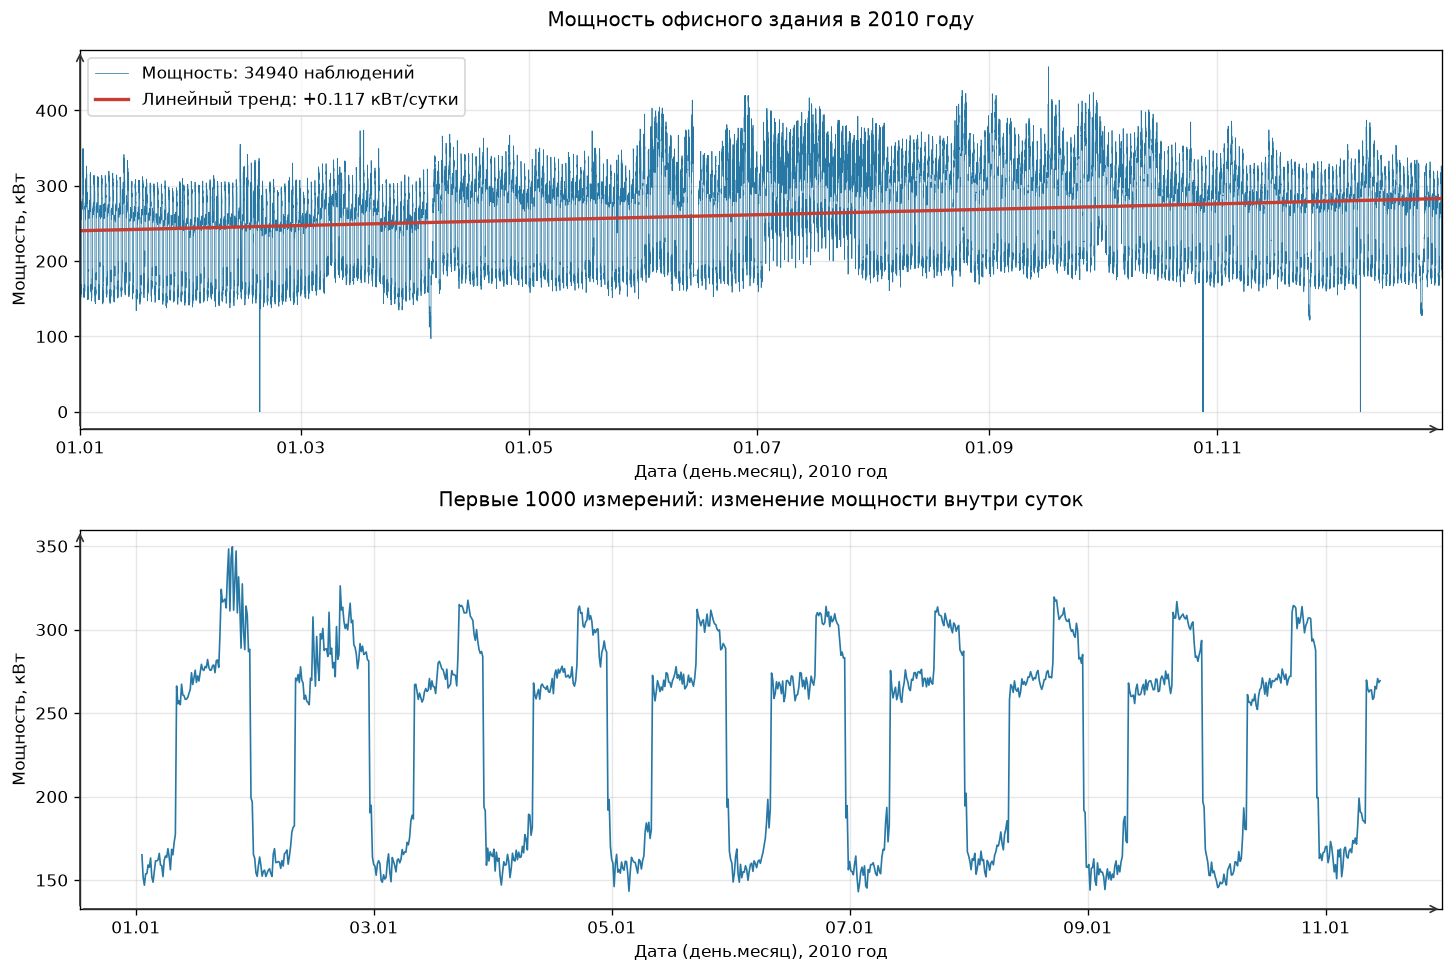

In [3]:
t = power['Timestamp']
y = power['Power (kW)']
days = (t - t.iloc[0]).dt.total_seconds().to_numpy() / 86400
slope, intercept = np.polyfit(days, y, 1)
fig, axs = plt.subplots(2, 1, figsize=(12, 8), layout='constrained')
axs[0].plot(t, y, linewidth=0.45, color='#2878a5', label=f'Мощность: {len(y)} наблюдений')
axs[0].plot(t, intercept + slope * days, color='#c63d32', linewidth=2,
            label=f'Линейный тренд: {slope:+.3f} кВт/сутки')
axs[0].set_title('Мощность офисного здания в 2010 году')
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
axs[0].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 3, 5, 7, 9, 11]))
axs[0].set_xlim(pd.Timestamp('2010-01-01'), t.max())
axs[0].legend(loc='upper left')
axs[1].plot(t.iloc[:1000], y.iloc[:1000], linewidth=1, color='#2878a5')
axs[1].set_title('Первые 1000 измерений: изменение мощности внутри суток')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
for ax in axs:
    axes_style(ax, 'Дата (день.месяц), 2010 год', 'Мощность, кВт', arrows=True)
finish(fig, '01_line.png')

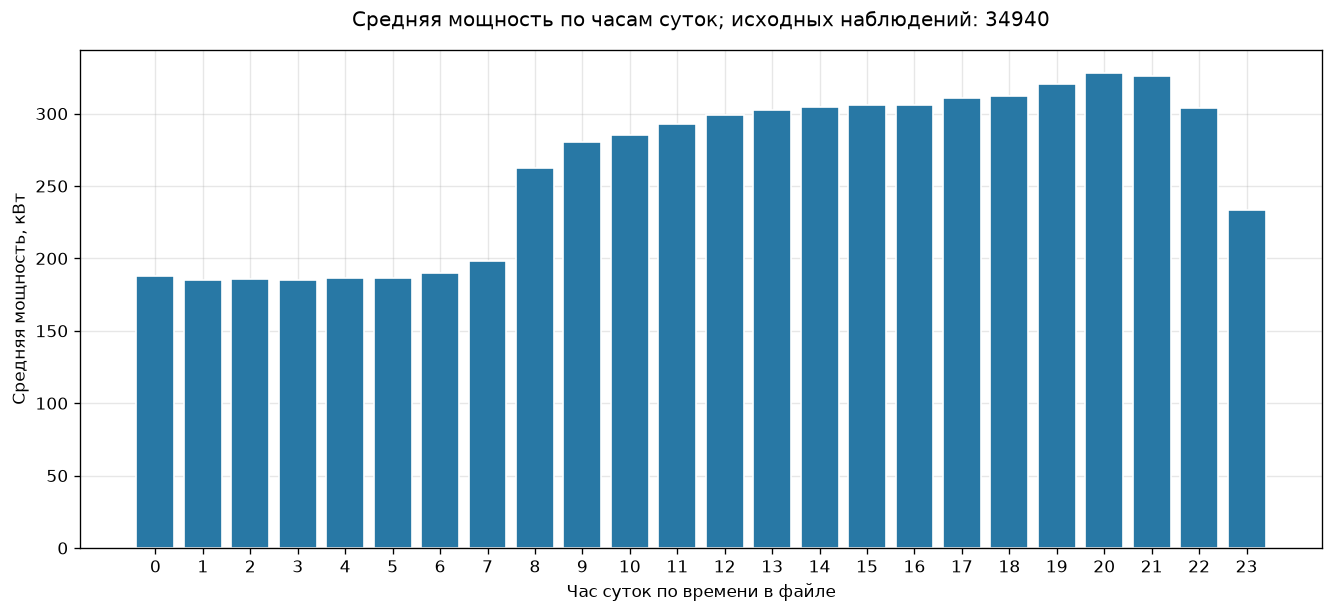

In [4]:
hourly = power.groupby(t.dt.hour)['Power (kW)'].agg(['mean', 'count'])
assert hourly['count'].sum() == len(power)
fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
ax.bar(hourly.index, hourly['mean'], color='#2878a5', edgecolor='white')
ax.set_xticks(range(24))
ax.set_title(f'Средняя мощность по часам суток; исходных наблюдений: {len(power)}')
axes_style(ax, 'Час суток по времени в файле', 'Средняя мощность, кВт')
finish(fig, '02_bar.png')

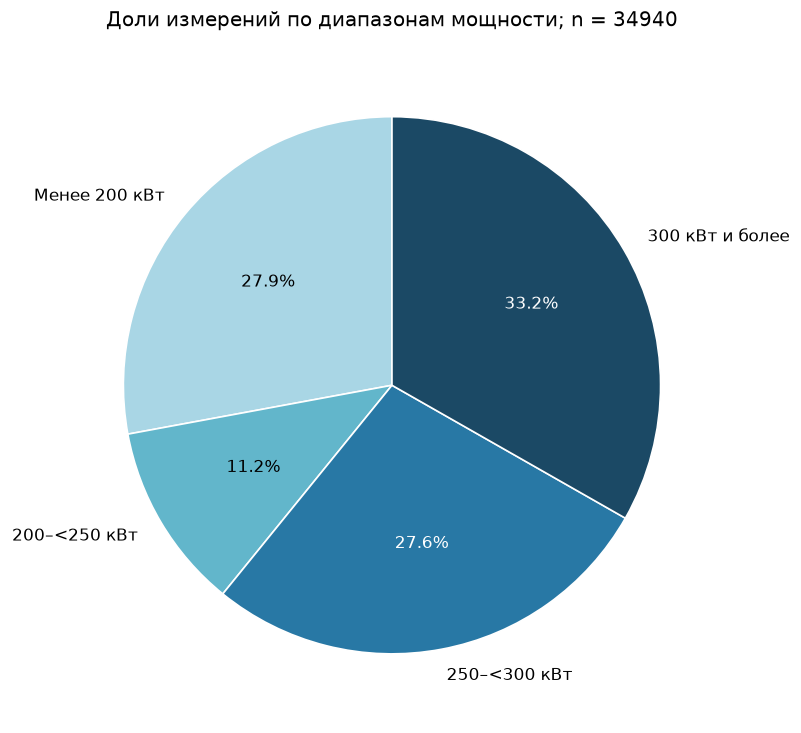

                 Число наблюдений  Доля, %
Power (kW)                                
Менее 200 кВт                9753    27.91
200–<250 кВт                 3928    11.24
250–<300 кВт                 9645    27.60
300 кВт и более             11614    33.24


In [5]:
labels = ['Менее 200 кВт', '200–<250 кВт', '250–<300 кВт', '300 кВт и более']
categories = pd.cut(y, [-np.inf, 200, 250, 300, np.inf], labels=labels, right=False)
counts = categories.value_counts(sort=False)
assert counts.sum() == len(power)
fig, ax = plt.subplots(figsize=(9, 6), layout='constrained')
wedges, texts, percentages = ax.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90,
       colors=['#a9d6e5', '#62b6cb', '#2878a5', '#1b4965'],
       wedgeprops={'edgecolor': 'white'})
for label in percentages[2:]:
    label.set_color('white')
ax.set_title(f'Доли измерений по диапазонам мощности; n = {len(power)}')
finish(fig, '03_pie.png')
print(pd.DataFrame({'Число наблюдений': counts, 'Доля, %': counts / len(y) * 100}).round(2))

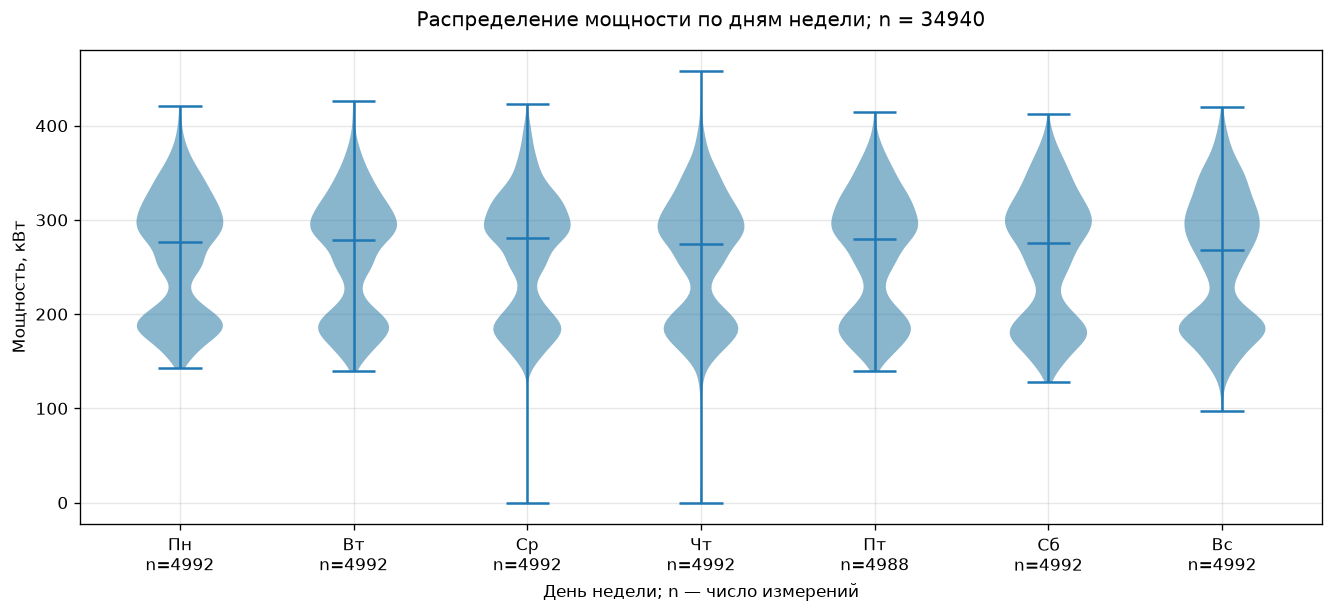

In [6]:
week_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
groups = [y[t.dt.dayofweek == day].to_numpy() for day in range(7)]
assert sum(map(len, groups)) == len(power)
fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
violin = ax.violinplot(groups, positions=np.arange(1, 8), showmedians=True)
for body in violin['bodies']:
    body.set_facecolor('#2878a5')
    body.set_alpha(0.55)
ax.set_xticks(range(1, 8), [f'{d}\nn={len(g)}' for d, g in zip(week_names, groups)])
ax.set_title(f'Распределение мощности по дням недели; n = {len(power)}')
axes_style(ax, 'День недели; n — число измерений', 'Мощность, кВт')
finish(fig, '04_violin.png')

## 3. Качественный анализ
Электрическая мощность показывает интенсивность потребления в момент измерения.
Для офисного здания возможны суточные изменения из-за освещения, оборудования
и прочего.

In [7]:
week_mean = y[t.dt.dayofweek < 5].mean()
weekend_mean = y[t.dt.dayofweek >= 5].mean()
correlation = power['Temperature (C)'].corr(y)
dominant = counts.idxmax()
print(f'Средняя мощность — {y.mean():.2f} кВт; медиана — {y.median():.2f} кВт.')
print(f'Диапазон — {y.min():.1f}–{y.max():.1f} кВт.')
print(f'Минимум среднего суточного профиля: {hourly["mean"].idxmin():02d}:00, '
      f'{hourly["mean"].min():.2f} кВт; максимум: {hourly["mean"].idxmax():02d}:00, '
      f'{hourly["mean"].max():.2f} кВт.')
print(f'Будни: {week_mean:.2f} кВт, выходные: {weekend_mean:.2f} кВт. '
      f'Разница (выходные минус будни): {weekend_mean-week_mean:+.2f} кВт.')
print(f'Самая частая категория: {dominant}, {100*counts.max()/len(y):.2f}% измерений.')
print(f'Наклон общего линейного тренда: {slope:+.4f} кВт/сутки '
      f'({"рост" if slope > 0 else "снижение"}). Это усреднение, а не монотонное изменение.')
print(f'Корреляция температуры и мощности: {correlation:.3f}. '
      'Связь не доказывает причинность и может отражать время суток или сезон.')
print('Широкие участки скрипок показывают наиболее частые уровни мощности. '
      'Разные режимы нагрузки могут объяснять несколько утолщений распределения.')
print('Нулевые значения требуют предметной проверки: возможны остановка оборудования '
      'или ошибка измерения, но по этому файлу различить их нельзя.')

Средняя мощность — 261.64 кВт; медиана — 276.70 кВт.
Диапазон — 0.0–457.9 кВт.
Минимум среднего суточного профиля: 01:00, 185.10 кВт; максимум: 20:00, 327.88 кВт.
Будни: 262.71 кВт, выходные: 258.97 кВт. Разница (выходные минус будни): -3.74 кВт.
Самая частая категория: 300 кВт и более, 33.24% измерений.
Наклон общего линейного тренда: +0.1174 кВт/сутки (рост). Это усреднение, а не монотонное изменение.
Корреляция температуры и мощности: 0.627. Связь не доказывает причинность и может отражать время суток или сезон.
Широкие участки скрипок показывают наиболее частые уровни мощности. Разные режимы нагрузки могут объяснять несколько утолщений распределения.
Нулевые значения требуют предметной проверки: возможны остановка оборудования или ошибка измерения, но по этому файлу различить их нельзя.


На линейном графике виден повторяющийся суточный профиль, а на скрипичных —
два выраженных скопления около 190 и 300 кВт. Это согласуется с низкой ночной
и более высокой дневной/вечерней нагрузкой. Максимум среднего профиля приходится
на 20:00, поэтому объяснение только присутствием сотрудников было бы недостаточным.
Средние в будни и выходные отличаются примерно на 3,74 кВт (около 1,4% среднего
будней), а формы скрипок похожи: сильного недельного различия здесь не видно.
Треть измерений относится к категории от 300 кВт. Это доля измерений, а не доля
суммарной энергии. Положительная корреляция с температурой (0,627) согласуется
с возможным ростом нагрузки систем охлаждения, но не позволяет отделить этот
эффект от суточных и сезонных изменений.

## 4. Прореживание и пять способов заполнения
Берём 41 последовательное измерение (строки данных 7–47, нумерация с 1).
Оставляем первое и далее каждое второе: позиции 1, 3, …, 41.
Удаляем 20 значений в позициях 2, 4, …, 40; обе границы остаются известными.
Время интерполяции измеряем в минутах от начала фрагмента.

Среднее и медиану считаем только по 21 сохранённому значению фрагмента.
Для среднего трёх предыдущих известных наблюдений берём именно исходные
сохранённые точки, а не уже восстановленные. Для первых пропусков используем
предысторию: строки 1, 3, 5 того же ряда, также с шагом через одно наблюдение.
Это позволяет не подменять среднее трёх значений средним одного или двух.

Многочлен Лагранжа строим по всем 21 узлам фрагмента (степень не выше 20).
Его колебания возле границ не скрываем: такая особенность показана на стр. 27 PDF.
Кубический сплайн строим с естественными условиями S''=0 на концах.
Все удалённые точки внутри интервала известных узлов: экстраполяции нет.

In [8]:
segment = power.iloc[6:47].copy().reset_index(drop=True)
x = (segment['Timestamp'] - segment['Timestamp'].iloc[0]).dt.total_seconds().to_numpy() / 60
actual = segment['Power (kW)'].to_numpy(copy=True)
observed = actual.copy()
missing = np.arange(len(actual)) % 2 == 1
observed[missing] = np.nan
known = ~missing
assert missing.sum() == 20 and known.sum() == 21

def lagrange(x_known, y_known, x_new):
    """L(x) = sum_i y_i * product_{j != i} (x-x_j)/(x_i-x_j), PDF стр. 25."""
    # Масштабирование аргумента сохраняет полином и уменьшает величины произведений.
    center = (x_known.min() + x_known.max()) / 2
    scale = (x_known.max() - x_known.min()) / 2
    nodes = (x_known - center) / scale
    points = (np.asarray(x_new) - center) / scale
    result = np.zeros_like(points, dtype=float)
    for i in range(len(nodes)):
        basis = np.ones_like(points, dtype=float)
        for j in range(len(nodes)):
            if i != j:
                basis *= (points - nodes[j]) / (nodes[i] - nodes[j])
        result += y_known[i] * basis
    return result

restored = {}
for name, value in [('Среднее', np.nanmean(observed)), ('Медиана', np.nanmedian(observed))]:
    filled = observed.copy()
    filled[missing] = value
    restored[name] = filled

filled = observed.copy()
history = power.iloc[[0, 2, 4]]['Power (kW)'].tolist()
for i, value in enumerate(observed):
    if np.isnan(value):
        filled[i] = np.mean(history[-3:])
    else:
        history.append(value)
restored['Три предыдущих'] = filled

filled = observed.copy()
filled[missing] = lagrange(x[known], observed[known], x[missing])
restored['Лагранж'] = filled
spline = CubicSpline(x[known], observed[known], bc_type='natural', extrapolate=False)
filled = observed.copy()
filled[missing] = spline(x[missing])
restored['Кубический сплайн'] = filled

for values in restored.values():
    assert np.isfinite(values).all()
    np.testing.assert_array_equal(values[known], actual[known])
np.testing.assert_allclose(lagrange(x[known], observed[known], x[known]), observed[known], atol=1e-8)
np.testing.assert_allclose(spline(x[known]), observed[known], atol=1e-8)

comparison = pd.DataFrame({'Позиция': np.arange(1, 42), 'Время': segment['Timestamp'],
                           'Реальное': actual, 'После прореживания': observed, **restored})
comparison.to_csv(RESULTS / 'restoration.csv', index=False, encoding='utf-8-sig')
print(f'Фрагмент: {segment.Timestamp.iloc[0]} — {segment.Timestamp.iloc[-1]}')
print(f'Среднее известных: {np.nanmean(observed):.3f}; медиана: {np.nanmedian(observed):.3f} кВт')
print(comparison.loc[missing].drop(columns='После прореживания').round(
    {col: 3 for col in comparison.select_dtypes('number').columns}).to_string(index=False))

Фрагмент: 2010-01-01 02:45:00 — 2010-01-01 12:45:00
Среднее известных: 211.200; медиана: 172.500 кВт
 Позиция               Время  Реальное  Среднее  Медиана  Три предыдущих   Лагранж  Кубический сплайн
       2 2010-01-01 03:00:00     163.2    211.2    172.5         152.800 60822.239            153.821
       4 2010-01-01 03:30:00     148.7    211.2    172.5         154.400 -5010.050            152.511
       6 2010-01-01 04:00:00     161.5    211.2    172.5         154.833   937.494            158.084
       8 2010-01-01 04:30:00     162.0    211.2    172.5         156.100   -11.055            165.089
      10 2010-01-01 05:00:00     159.0    211.2    172.5         160.867   217.719            162.334
      12 2010-01-01 05:30:00     152.1    211.2    172.5         162.033   135.679            159.238
      14 2010-01-01 06:00:00     164.4    211.2    172.5         162.200   176.773            163.638
      16 2010-01-01 06:30:00     168.8    211.2    172.5         161.400   153.599 

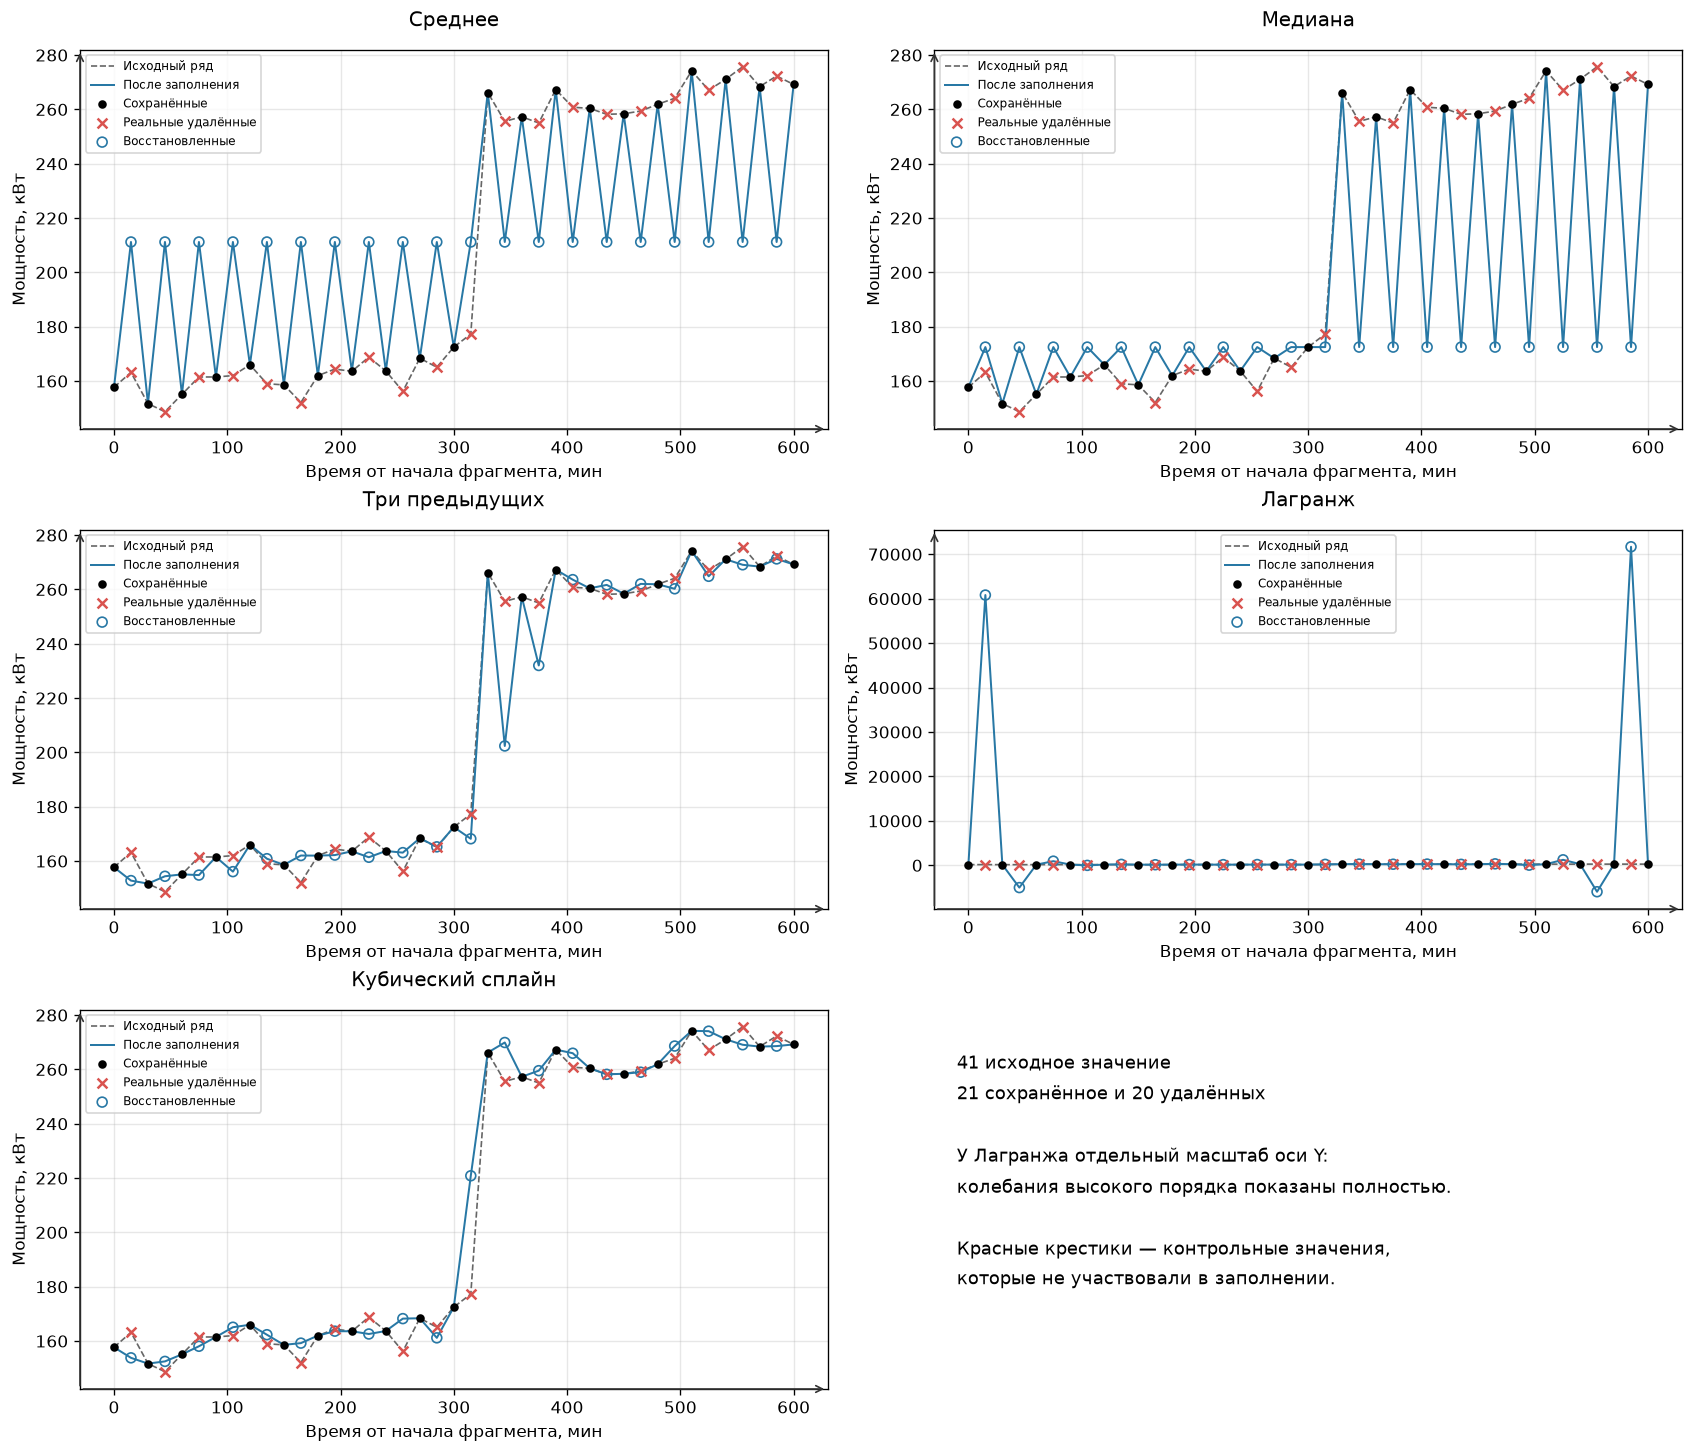

In [9]:
fig, axs = plt.subplots(3, 2, figsize=(14, 12), layout='constrained')
for ax, (name, values) in zip(axs.flat, restored.items()):
    ax.plot(x, actual, '--', color='#666666', linewidth=1, label='Исходный ряд')
    ax.plot(x, values, color='#2878a5', linewidth=1.2, label='После заполнения')
    ax.scatter(x[known], observed[known], color='black', s=17, zorder=4, label='Сохранённые')
    ax.scatter(x[missing], actual[missing], color='#d9534f', marker='x', s=35,
               zorder=5, label='Реальные удалённые')
    ax.scatter(x[missing], values[missing], facecolors='none', edgecolors='#2878a5',
               s=35, zorder=4, label='Восстановленные')
    ax.set_title(name)
    axes_style(ax, 'Время от начала фрагмента, мин', 'Мощность, кВт', arrows=True)
    ax.legend(fontsize=7, loc='best')
axs.flat[-1].axis('off')
axs.flat[-1].text(0.03, 0.9, '41 исходное значение\n21 сохранённое и 20 удалённых\n\n'
                 'У Лагранжа отдельный масштаб оси Y:\n'
                 'колебания высокого порядка показаны полностью.\n\n'
                 'Красные крестики — контрольные значения,\n'
                 'которые не участвовали в заполнении.',
                 transform=axs.flat[-1].transAxes, va='top', fontsize=11, linespacing=1.7)
finish(fig, '05_restoration.png')

## 5. Ошибки восстановления и выбросы
Для диагностики выбираем кубический сплайн. Считаем только 20 удалённых точек.
Знаковая ошибка e = восстановленное − реальное: положительная означает завышение.
Для 2σ и 3σ сравниваем |e − mean(e)| с 2s и 3s, где s — выборочное
стандартное отклонение (ddof=1).
Для box-plot используем границы Q1 − 1,5 IQR и Q3 + 1,5 IQR.
Ничего автоматически не удаляем. Скрипичная диаграмма при n=20 носит иллюстративный характер.

In [10]:
error = restored['Кубический сплайн'][missing] - actual[missing]
mu = error.mean()
sigma = error.std(ddof=1)
q1, q3 = np.quantile(error, [0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flags2 = np.abs(error - mu) > 2 * sigma
flags3 = np.abs(error - mu) > 3 * sigma
flags_iqr = (error < lower) | (error > upper)
errors = pd.DataFrame({'Позиция': np.flatnonzero(missing) + 1,
                       'Время': segment.loc[missing, 'Timestamp'].to_numpy(),
                       'Реальное, кВт': actual[missing],
                       'Сплайн, кВт': restored['Кубический сплайн'][missing],
                       'Ошибка, кВт': error, 'За 2 сигма': flags2,
                       'За 3 сигма': flags3, 'За 1.5 IQR': flags_iqr})
errors.to_csv(RESULTS / 'errors_spline.csv', index=False, encoding='utf-8-sig')
round_columns = {col: 3 for col in errors.select_dtypes('number').columns}
print(errors.round(round_columns).to_string(index=False))
print(f'Средняя знаковая ошибка: {mu:.3f} кВт; s = {sigma:.3f} кВт.')
print(f'Границы 2σ: [{mu-2*sigma:.3f}; {mu+2*sigma:.3f}], выбросов: {flags2.sum()}.')
print(f'Границы 3σ: [{mu-3*sigma:.3f}; {mu+3*sigma:.3f}], выбросов: {flags3.sum()}.')
print(f'Q1={q1:.3f}; Q3={q3:.3f}; IQR={iqr:.3f}. '
      f'Границы IQR: [{lower:.3f}; {upper:.3f}], выбросов: {flags_iqr.sum()}.')
flagged = errors.loc[flags2 | flags3 | flags_iqr]
print('\nНеобычные ошибки (объединение критериев):')
print(flagged.round(round_columns).to_string(index=False) if len(flagged) else 'Не обнаружены.')

 Позиция               Время  Реальное, кВт  Сплайн, кВт  Ошибка, кВт  За 2 сигма  За 3 сигма  За 1.5 IQR
       2 2010-01-01 03:00:00          163.2      153.821       -9.379       False       False       False
       4 2010-01-01 03:30:00          148.7      152.511        3.811       False       False       False
       6 2010-01-01 04:00:00          161.5      158.084       -3.416       False       False       False
       8 2010-01-01 04:30:00          162.0      165.089        3.089       False       False       False
      10 2010-01-01 05:00:00          159.0      162.334        3.334       False       False       False
      12 2010-01-01 05:30:00          152.1      159.238        7.138       False       False       False
      14 2010-01-01 06:00:00          164.4      163.638       -0.762       False       False       False
      16 2010-01-01 06:30:00          168.8      162.599       -6.201       False       False       False
      18 2010-01-01 07:00:00          156.2   

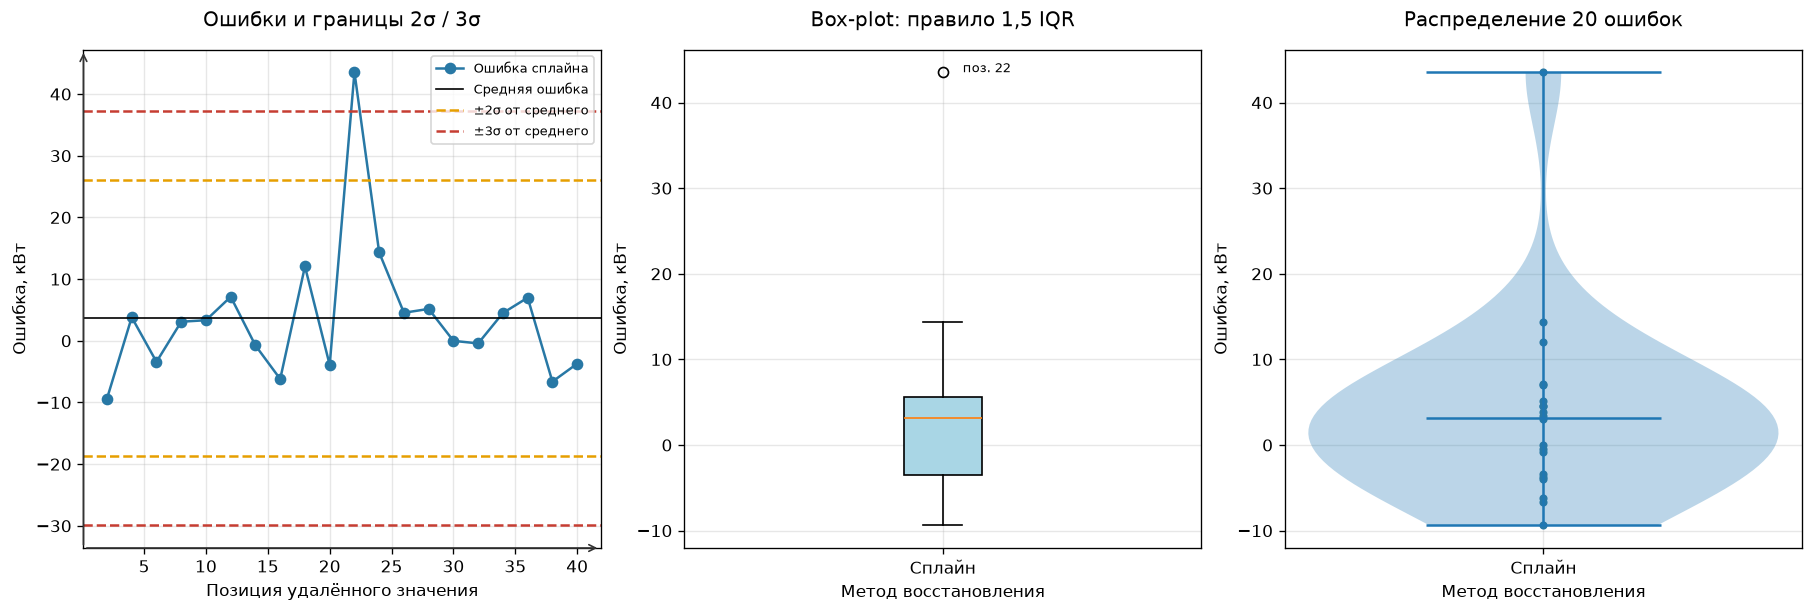

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), layout='constrained')
positions = errors['Позиция']
axs[0].plot(positions, error, 'o-', color='#2878a5', label='Ошибка сплайна')
axs[0].axhline(mu, color='black', linewidth=1, label='Средняя ошибка')
for k, color in [(2, '#e69f00'), (3, '#c63d32')]:
    axs[0].axhline(mu + k * sigma, color=color, linestyle='--', label=f'±{k}σ от среднего')
    axs[0].axhline(mu - k * sigma, color=color, linestyle='--')
axs[0].set_title('Ошибки и границы 2σ / 3σ')
axes_style(axs[0], 'Позиция удалённого значения', 'Ошибка, кВт', arrows=True)
axs[0].legend(fontsize=8)
axs[1].boxplot(error, whis=1.5, tick_labels=['Сплайн'], patch_artist=True,
               boxprops={'facecolor': '#a9d6e5'})
axs[1].set_title('Box-plot: правило 1,5 IQR')
axes_style(axs[1], 'Метод восстановления', 'Ошибка, кВт')
axs[2].violinplot(error, showmedians=True)
axs[2].scatter(np.ones(len(error)), error, s=15, color='#2878a5')
axs[2].set_xticks([1], ['Сплайн'])
axs[2].set_title('Распределение 20 ошибок')
axes_style(axs[2], 'Метод восстановления', 'Ошибка, кВт')
for i in np.flatnonzero(flags_iqr):
    axs[1].annotate(f'поз. {positions.iloc[i]}', (1, error[i]), xytext=(12, 0),
                    textcoords='offset points', fontsize=8)
finish(fig, '06_errors.png')

## Вывод по восстановлению
Среднее и медиана дают постоянные заполнения и не передают локальные изменения.
Среднее трёх предыдущих известных значений учитывает недавний уровень ряда,
но при резком росте или падении запаздывает. Лагранж точно проходит через известные
точки, однако полином высокой степени может сильно колебаться между ними.
Кубический сплайн использует соседние участки ряда и даёт гладкое восстановление,
но также может ошибаться на резких переключениях нагрузки.
Проверка узлов интерполяции не заменяет проверку на удалённых значениях.
Выводы этого опыта относятся к выбранному фрагменту, а не ко всему году.
В выбранном фрагменте сплайн завышает значение в 08:00: после сохранённой точки
07:45 (172,5 кВт) следует точка 08:15 (266,2 кВт). Гладкая кривая начинает рост
раньше фактического скачка и даёт 220,845 кВт вместо удалённых 177,3 кВт.
Именно эта ошибка отмечена всеми тремя критериями.

In [12]:
lag_removed = restored['Лагранж'][missing]
worst = int(np.argmax(np.abs(error)))
print(f'Лагранж: диапазон восстановленных значений {lag_removed.min():.2f}–{lag_removed.max():.2f} кВт; '
      f'отрицательных значений: {int((lag_removed < 0).sum())}.')
print(f'Сплайн: наибольшая по модулю ошибка {error[worst]:+.3f} кВт '
      f'в позиции {positions.iloc[worst]} ({errors["Время"].iloc[worst]}).')
print(f'Критерии отметили {flags2.sum()} ошибок по 2σ, {flags3.sum()} по 3σ '
      f'и {flags_iqr.sum()} по IQR. Перечень точек приведён выше.')
print('Эти флаги характеризуют отклонения восстановленных значений. '
      'Они сами по себе не доказывают, что исходные измерения ошибочны.')

Лагранж: диапазон восстановленных значений -5944.35–71684.48 кВт; отрицательных значений: 3.
Сплайн: наибольшая по модулю ошибка +43.545 кВт в позиции 22 (2010-01-01 08:00:00).
Критерии отметили 1 ошибок по 2σ, 1 по 3σ и 1 по IQR. Перечень точек приведён выше.
Эти флаги характеризуют отклонения восстановленных значений. Они сами по себе не доказывают, что исходные измерения ошибочны.
